# Tugas 1: Pengolahan Citra Digital (PCD_Assignment01)
## Eksperimen dan Analisis Spasial Sampling Citra Digital
**Topik**: Downsampling (Max, Average, Median) dan Upsampling (Nearest Neighbor, Bilinear, Bicubic)  
**Repositori GitHub**: [github.com/hanafishiddiq/PCD_Assignment01](https://github.com/hanafishiddiq/PCD_Assignment01)

---
### Tujuan
Notebook ini bertujuan untuk menganalisis fenomena spasial sampling pada citra digital:
1. **Downsampling (Reduksi Resolusi)**: Menganalisis pengaruh tiga operator downsampling spasial (**Max Downsampling**, **Average Downsampling**, dan **Median Downsampling**) terhadap energi sinyal, kecerahan rata-rata, dan edge retention pada gambar.
2. **Upsampling (Rekonstruksi Citra)**: Membandingkan performa tiga metode interpolasi (**Nearest Neighbor**, **Bilinear**, dan **Bicubic Keys Interpolation**) dalam memulihkan citra ke dimensi asal.
3. **Karakteristik Citra Uji (4 Domain Kontras)**:
   - **Citra 1 (Baboon / Mandrill)**: Tekstur frekuensi tinggi (bulu, kumis halus) yang sangat sensitif terhadap *aliasing*.
   - **Citra 2 (Architectural Building)**: Tepi geometris tajam (kisi-kisi jendela, garis kolom arsitektur) yang sensitif terhadap efek tangga piksel (*jaggies*).
   - **Citra 3 (Astronaut)**: Gradasi halus dan transisi warna kontinu (kulit wajah, pantulan kaca helm) untuk mengevaluasi kehalusan interpolasi.
   - **Citra 4 (Gravel / Kerikil)**: Pola stokastik dan derau organik alami untuk menguji ketahanan filtering terhadap nilai-nilai ekstrem lokal.

In [1]:
import os
import urllib.request
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from skimage.metrics import structural_similarity as ssim_fn

# Standarisasi konfigurasi tipografi dan perenderan plot
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 100

print(f"NumPy Version   : {np.__version__}")
print(f"OpenCV Version  : {cv2.__version__}")


NumPy Version   : 2.4.6
OpenCV Version  : 5.0.0


---
## 1. Implementasi Algoritma Downsampling

Operasi downsampling dengan faktor $k$ bekerja dengan membagi citra menjadi blok-blok kecil berukuran $k \times k$ piksel. Setiap blok (kita sebut blok $B$) kemudian disederhanakan menjadi **satu piksel baru** menggunakan tiga metode:

1. **Max Downsampling**
   $$\text{Piksel Baru} = \max(B)$$
   *Cara kerja*: Mengambil nilai piksel tertinggi (paling terang) di dalam blok.  
   *Karakteristik*: Citra tampak lebih terang secara keseluruhan. Menonjolkan fitur terang, namun gradasi halus dan detail area gelap cenderung hilang.

2. **Average Downsampling**
   $$\text{Piksel Baru} = \frac{1}{k^2} \sum_{p \in B} p$$
   *Cara kerja*: Menghitung nilai rata-rata dari seluruh piksel di dalam blok.  
   *Karakteristik*: Menjaga kecerahan alami citra dan efektif meredam efek gerigi (*aliasing*), meskipun garis tepi tajam menjadi sedikit lebih lembut.

3. **Median Downsampling**
   $$\text{Piksel Baru} = \text{median}(B)$$
   *Cara kerja*: Mengurutkan seluruh piksel di dalam blok, lalu mengambil nilai tepat di posisi tengah.  
   *Karakteristik*: Sangat efektif mempertahankan ketajaman garis kontur dan tahan terhadap gangguan *salt-and-pepper noise*.

> **Ilustrasi (Blok $2 \times 2$):**  
> Misalkan terdapat satu blok piksel berukuran $2 \times 2$: $\begin{bmatrix} 10 & 20 \\ 30 & 80 \end{bmatrix}$  
> - **Max** $\rightarrow \max(10, 20, 30, 80) = \mathbf{80}$ *(mengambil piksel paling terang)*  
> - **Average** $\rightarrow \frac{10 + 20 + 30 + 80}{4} = \mathbf{35}$ *(meratakan seluruh nilai)*  
> - **Median** $\rightarrow \text{nilai tengah dari } \{10, 20, 30, 80\} = \mathbf{25}$

In [2]:
def _prepare_blocks(image: np.ndarray, factor: int):
    """Memecah citra 2D atau 3D menjadi blok 5D (H_out, W_out, factor, factor, C) untuk vektorisasi murni."""
    is_2d = image.ndim == 2
    img_3d = image[:, :, None] if is_2d else image
    h, w, c = img_3d.shape
    h_crop = h - (h % factor)
    w_crop = w - (w % factor)
    cropped = img_3d[:h_crop, :w_crop, :]
    h_out, w_out = h_crop // factor, w_crop // factor
    blocks = cropped.reshape(h_out, factor, w_out, factor, c).swapaxes(1, 2)
    return blocks, is_2d

def downsample(image: np.ndarray, factor: int = 2, method: str = 'average') -> np.ndarray:
    """Downsample citra spasial menggunakan metode 'max', 'average', atau 'median'."""
    blocks, is_2d = _prepare_blocks(image, factor)
    if method == 'max':
        res = blocks.max(axis=(2, 3))
    elif method == 'average':
        res = np.round(blocks.mean(axis=(2, 3))).astype(np.uint8)
    elif method == 'median':
        h_out, w_out, _, _, c = blocks.shape
        flattened = blocks.reshape(h_out, w_out, factor * factor, c)
        res = np.round(np.median(flattened, axis=2)).astype(np.uint8)
    else:
        raise ValueError(f"Metode downsample tidak valid: {method}")
    return res[:, :, 0] if is_2d else res


---
## 2. Implementasi Algoritma Upsampling / Interpolasi

Operasi upsampling bertujuan memperbesar dimensi citra (misal dengan faktor perbesaran skala $s$). Untuk menentukan warna pada setiap koordinat piksel baru $(x, y)$, nilainya diestimasi dari kisi citra asal melalui tiga pendekatan interpolasi:

1. **Nearest Neighbor (NN)**
   $$u = \left\lfloor x \cdot \frac{W_{\text{in}}}{W_{\text{out}}} \right\rfloor, \quad v = \left\lfloor y \cdot \frac{H_{\text{in}}}{H_{\text{out}}} \right\rfloor$$
   $$\text{Piksel Baru}(x, y) = \text{CitraAsal}(u, v)$$
   $$\text{Intuisinya: } \mathbf{\text{Piksel Baru} = \text{Warna Piksel Asal Terdekat}}$$
   *Cara kerja*: Koordinat target $(x, y)$ pada citra perbesaran langsung dipetakan ke indeks piksel terdekat pada citra asal dengan pembulatan ke bawah (*floor step*), lalu langsung menjiplak nilainya tanpa perhitungan bobot tambahan.  
   *Karakteristik*: Komputasi paling cepat dan efisien (tanpa perhitungan tetangga), namun menghasilkan artefak undakan tangga atau kotak-kotak yang kasar (*blocky pixelation / jaggies*).

Pada **Bilinear** dan **Bicubic Interpolation**, koordinat sub-piksel dihitung secara kontinu menggunakan titik tengah fraksional $(u, v)$:
$$u = (x + 0.5) \cdot \frac{W_{\text{in}}}{W_{\text{out}}} - 0.5, \quad v = (y + 0.5) \cdot \frac{H_{\text{in}}}{H_{\text{out}}} - 0.5$$

2. **Bilinear Interpolation**
   Dengan menentukan koordinat 4 piksel tetangga terdekat di sekeliling $(u, v)$:
   $$u_0 = \lfloor u \rfloor, \quad u_1 = u_0 + 1, \quad \Delta x = u - u_0$$
   $$v_0 = \lfloor v \rfloor, \quad v_1 = v_0 + 1, \quad \Delta y = v - v_0$$
   Nilai piksel baru dihitung melalui rata-rata tertimbang dari **4 piksel tetangga** ($2 \times 2$):
   $$\text{Piksel Baru} = (1 - \Delta x)(1 - \Delta y) \text{CitraAsal}(u_0, v_0) + \Delta x (1 - \Delta y) \text{CitraAsal}(u_1, v_0) + (1 - \Delta x) \Delta y \text{CitraAsal}(u_0, v_1) + \Delta x \Delta y \text{CitraAsal}(u_1, v_1)$$
   *Cara kerja*: Melakukan interpolasi linear dua arah (horizontal lalu vertikal). Walaupun rumusnya terlihat rumit, namun intuisinya hanya mengambil rata-rata berbobot dari 4 tetangga terdekat: semakin dekat posisi titik baru ke suatu piksel, semakin besar pengaruh (bobot) nilai piksel tersebut terhadap hasil akhirnya.  
   *Karakteristik*: Mengeliminasi efek tangga (*jaggies*) dengan transisi warna yang halus, namun garis kontur yang sangat tajam menjadi sedikit kabur (*smoothing blur*).

3. **Bicubic Interpolation**
   Memperhitungkan **16 piksel tetangga** ($4 \times 4$) menggunakan fungsi bobot konvolusi kubik Keys ($a = -0.5$, aproksimasi Catmull-Rom spline):
   $$W(x) = \begin{cases} (a+2)|x|^3 - (a+3)|x|^2 + 1, & |x| \le 1 \\ a|x|^3 - 5a|x|^2 + 8a|x| - 4a, & 1 \lt |x| \lt 2 \\ 0, & \text{lainnya} \end{cases}$$
   *Cara kerja*: Menghitung bobot kurva polinomial kubik pada arah horizontal dan vertikal secara terpisah (*separable convolution*).  
   *Karakteristik*: Menghasilkan rekonstruksi paling halus dan tajam karena mempertahankan kurva kontur alami objek, meskipun beban komputasinya lebih tinggi (memperhitungkan 16 piksel tetangga).

In [3]:
def _keys_cubic_kernel(x: np.ndarray, a: float = -0.5) -> np.ndarray:
    """Fungsi kernel konvolusi kubik Keys (Catmull-Rom spline, a = -0.5)."""
    x_abs = np.abs(x)
    weights = np.zeros_like(x_abs, dtype=np.float32)
    m1 = x_abs <= 1.0
    m2 = (x_abs > 1.0) & (x_abs < 2.0)
    weights[m1] = (a + 2.0) * (x_abs[m1] ** 3) - (a + 3.0) * (x_abs[m1] ** 2) + 1.0
    weights[m2] = a * (x_abs[m2] ** 3) - 5.0 * a * (x_abs[m2] ** 2) + 8.0 * a * x_abs[m2] - 4.0 * a
    return weights

def _resolve_target_shape(image: np.ndarray, scale_or_shape):
    h_in, w_in = image.shape[:2]
    if isinstance(scale_or_shape, (int, float)):
        return max(1, int(round(h_in * scale_or_shape))), max(1, int(round(w_in * scale_or_shape)))
    return int(scale_or_shape[0]), int(scale_or_shape[1])

def upsample_nearest(image: np.ndarray, scale_or_shape=2) -> np.ndarray:
    """Upsampling interpolasi Nearest Neighbor (orde-0)."""
    h_out, w_out = _resolve_target_shape(image, scale_or_shape)
    h_in, w_in = image.shape[:2]
    y_coords = np.clip(np.floor(np.arange(h_out) * (h_in / h_out)).astype(np.int32), 0, h_in - 1)
    x_coords = np.clip(np.floor(np.arange(w_out) * (w_in / w_out)).astype(np.int32), 0, w_in - 1)
    return image[y_coords[:, None], x_coords[None, :]]

def upsample_bilinear(image: np.ndarray, scale_or_shape=2) -> np.ndarray:
    """Upsampling interpolasi Bilinear (pembobotan 4 tetangga)."""
    h_out, w_out = _resolve_target_shape(image, scale_or_shape)
    h_in, w_in = image.shape[:2]
    is_2d = image.ndim == 2
    img_3d = image[:, :, None] if is_2d else image

    y_in = (np.arange(h_out, dtype=np.float32) + 0.5) * (h_in / h_out) - 0.5
    x_in = (np.arange(w_out, dtype=np.float32) + 0.5) * (w_in / w_out) - 0.5

    y0 = np.clip(np.floor(y_in).astype(np.int32), 0, h_in - 1)
    x0 = np.clip(np.floor(x_in).astype(np.int32), 0, w_in - 1)
    y1 = np.clip(y0 + 1, 0, h_in - 1)
    x1 = np.clip(x0 + 1, 0, w_in - 1)

    dy = (y_in - y0).astype(np.float32)[:, None]
    dx = (x_in - x0).astype(np.float32)[None, :]

    p00 = img_3d[y0[:, None], x0[None, :], :]
    p01 = img_3d[y0[:, None], x1[None, :], :]
    p10 = img_3d[y1[:, None], x0[None, :], :]
    p11 = img_3d[y1[:, None], x1[None, :], :]

    w00 = ((1.0 - dy) * (1.0 - dx))[:, :, None]
    w01 = ((1.0 - dy) * dx)[:, :, None]
    w10 = (dy * (1.0 - dx))[:, :, None]
    w11 = (dy * dx)[:, :, None]

    out = p00 * w00 + p01 * w01 + p10 * w10 + p11 * w11
    out = np.clip(np.round(out), 0, 255).astype(np.uint8)
    return out[:, :, 0] if is_2d else out

def upsample_bicubic(image: np.ndarray, scale_or_shape=2, a: float = -0.5) -> np.ndarray:
    """Upsampling interpolasi Bicubic (konvolusi kubik 16 tetangga)."""
    h_out, w_out = _resolve_target_shape(image, scale_or_shape)
    h_in, w_in = image.shape[:2]
    is_2d = image.ndim == 2
    img_3d = image[:, :, None] if is_2d else image
    c = img_3d.shape[2]

    y_in = (np.arange(h_out, dtype=np.float32) + 0.5) * (h_in / h_out) - 0.5
    x_in = (np.arange(w_out, dtype=np.float32) + 0.5) * (w_in / w_out) - 0.5

    y_base = np.floor(y_in).astype(np.int32)
    x_base = np.floor(x_in).astype(np.int32)
    dy = (y_in - y_base).astype(np.float32)
    dx = (x_in - x_base).astype(np.float32)

    wy = np.zeros((4, h_out), dtype=np.float32)
    wx = np.zeros((4, w_out), dtype=np.float32)
    for i, offset in enumerate([-1, 0, 1, 2]):
        wy[i] = _keys_cubic_kernel(dy - offset, a=a)
        wx[i] = _keys_cubic_kernel(dx - offset, a=a)

    wy /= (wy.sum(axis=0, keepdims=True) + 1e-12)
    wx /= (wx.sum(axis=0, keepdims=True) + 1e-12)

    out = np.zeros((h_out, w_out, c), dtype=np.float32)
    for m_idx, m in enumerate([-1, 0, 1, 2]):
        y_coords = np.clip(y_base + m, 0, h_in - 1)
        w_m = wy[m_idx]
        for n_idx, n in enumerate([-1, 0, 1, 2]):
            x_coords = np.clip(x_base + n, 0, w_in - 1)
            w_n = wx[n_idx]
            w_mn = (w_m[:, None] * w_n[None, :])[:, :, None]
            out += img_3d[y_coords[:, None], x_coords[None, :], :] * w_mn

    out = np.clip(np.round(out), 0, 255).astype(np.uint8)
    return out[:, :, 0] if is_2d else out

def upsample(image: np.ndarray, scale_or_shape=2, method: str = 'bilinear') -> np.ndarray:
    """Antarmuka terpadu operasi upsampling."""
    if method == 'nearest':
        return upsample_nearest(image, scale_or_shape)
    elif method == 'bilinear':
        return upsample_bilinear(image, scale_or_shape)
    elif method == 'bicubic':
        return upsample_bicubic(image, scale_or_shape)
    raise ValueError(f"Metode upsample tidak valid: {method}")


---
## 3. Pemuatan Citra Uji Benchmark
Fungsi berikut memuat citra dari folder lokal jika ada, atau mengunduhnya langsung dari GitHub jika dijalankan di Google Colab.

Berikut adalah 4 citra uji dengan berbagai karakteristik untuk diuji:
1. **Baboon (Mandrill)**: Tekstur frekuensi tinggi (rambut, kumis).
2. **Architectural Building**: Tepi geometris kontras tinggi dan garis lurus pada arsitektur.
3. **Astronaut**: Gradien pencahayaan halus dan warna kulit lembut.
4. **Gravel (Kerikil)**: Pola stokastik alami dan *random noise*.

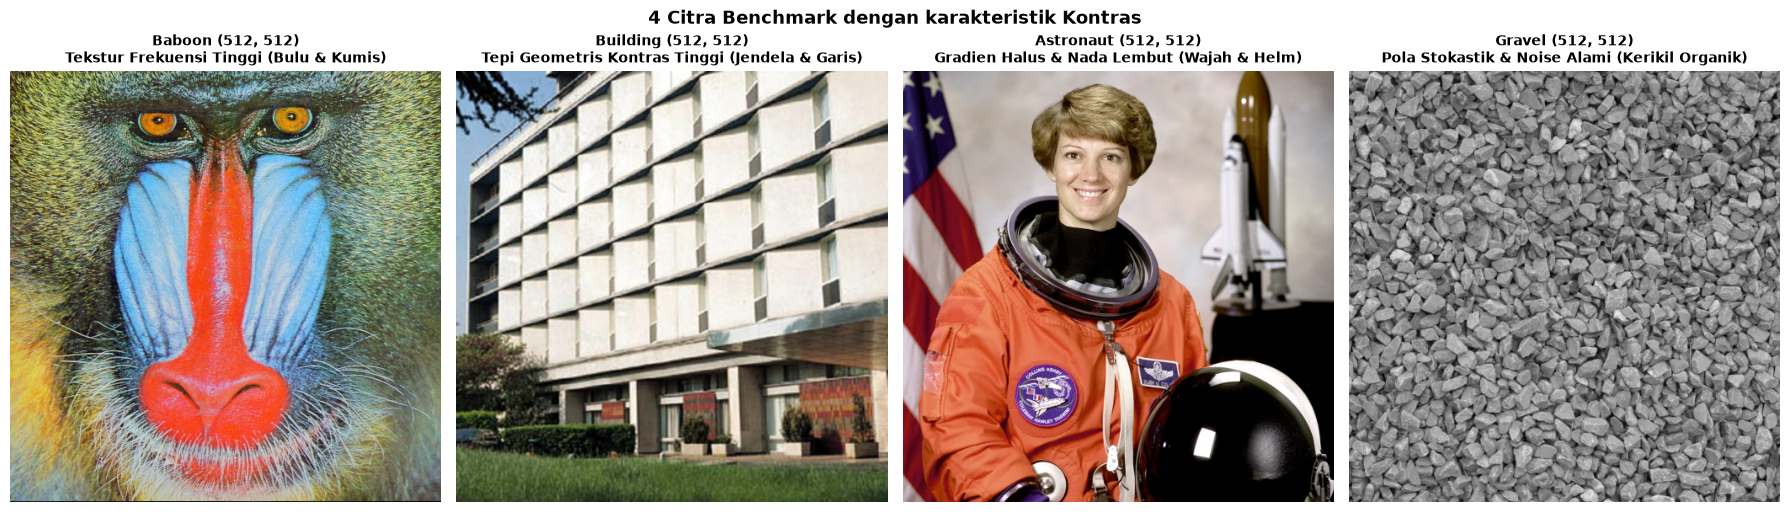

In [4]:
GITHUB_RAW_BASE = "https://raw.githubusercontent.com/hanafishiddiq/PCD_Assignment01/main/data/input"

def load_benchmark_image(filename: str) -> np.ndarray:
    """Memuat citra dari path lokal jika ada, atau mengunduh otomatis dari GitHub raw."""
    local_path = Path("data/input") / filename
    if local_path.exists():
        img_bgr = cv2.imread(str(local_path))
        return cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    
    url = f"{GITHUB_RAW_BASE}/{filename}"
    req = urllib.request.urlopen(url)
    arr = np.asarray(bytearray(req.read()), dtype=np.uint8)
    img_bgr = cv2.imdecode(arr, cv2.IMREAD_COLOR)
    return cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

benchmark_dataset = {
    "Baboon": {
        "img": load_benchmark_image("01_high_texture.png"),
        "desc": "Tekstur Frekuensi Tinggi (Bulu & Kumis)"
    },
    "Building": {
        "img": load_benchmark_image("02_geometric_edge.png"),
        "desc": "Tepi Geometris Kontras Tinggi (Jendela & Garis)"
    },
    "Astronaut": {
        "img": load_benchmark_image("03_smooth_gradient.png"),
        "desc": "Gradien Halus & Nada Lembut (Wajah & Helm)"
    },
    "Gravel": {
        "img": load_benchmark_image("04_natural_noise.png"),
        "desc": "Pola Stokastik & Noise Alami (Kerikil Organik)"
    }
}

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
for idx, (name, item) in enumerate(benchmark_dataset.items()):
    img = item["img"]
    axes[idx].imshow(img)
    axes[idx].set_title(f"{name} {img.shape[:2]}\n{item['desc']}", fontsize=10, fontweight='bold')
    axes[idx].axis('off')

plt.suptitle("4 Citra Benchmark dengan karakteristik Kontras", fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


---
## 4. Eksperimen 1: Analisis Efek Downsampling (Max, Average, Median)

Pada eksperimen ini, keempat citra di-downsample sebesar **faktor $4\times$** (dari dimensi $512 \times 512$ menjadi $128 \times 128$).
Faktor 4× dipilih karena pada faktor 2× penurunan detail belum terlalu terlihat perbedaannya, sedangkan pada 8× gambar sudah terlalu rusak; faktor 4× menjadi titik perbandingan yang paling pas untuk mengamati artefak dan kemampuan rekonstruksi tiap metode.

Kita menganalisis pergeseran statistik rata-rata intensitas dan kebertahanan tepi kontur pada masing-masing domain citra.

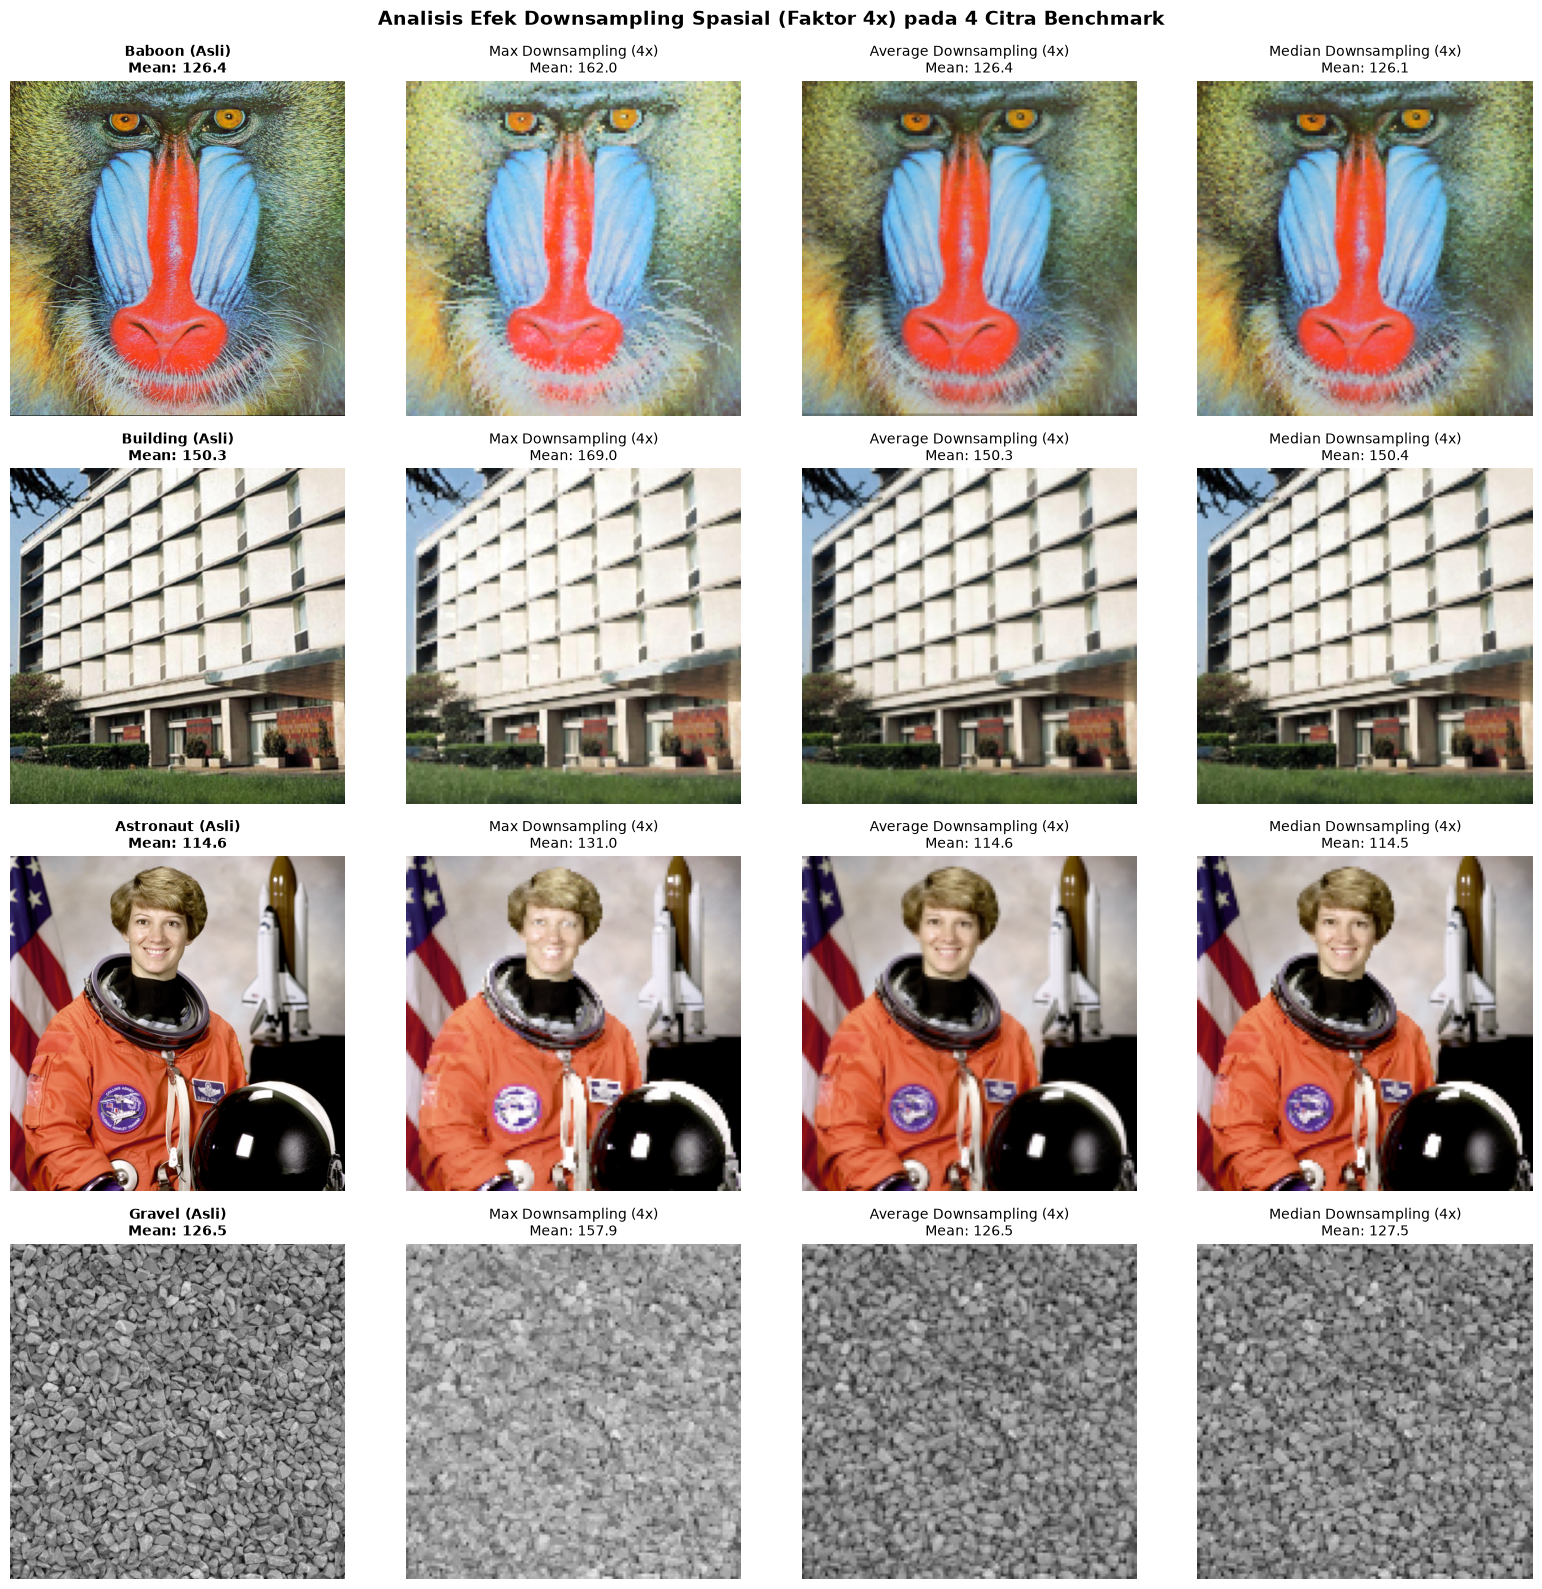

In [5]:
factor = 4
fig, axes = plt.subplots(4, 4, figsize=(16, 16))

downsampled_results = {}

for row_idx, (name, item) in enumerate(benchmark_dataset.items()):
    img = item["img"]
    down_max = downsample(img, factor=factor, method='max')
    down_avg = downsample(img, factor=factor, method='average')
    down_med = downsample(img, factor=factor, method='median')
    
    downsampled_results[name] = {
        "max": down_max,
        "average": down_avg,
        "median": down_med
    }
    
    # 1. Asli
    axes[row_idx, 0].imshow(img)
    axes[row_idx, 0].set_title(f"{name} (Asli)\nMean: {img.mean():.1f}", fontsize=10, fontweight='bold')
    axes[row_idx, 0].axis('off')
    
    # 2. Max Downsampling
    axes[row_idx, 1].imshow(down_max)
    axes[row_idx, 1].set_title(f"Max Downsampling ({factor}x)\nMean: {down_max.mean():.1f}", fontsize=10)
    axes[row_idx, 1].axis('off')
    
    # 3. Average Downsampling
    axes[row_idx, 2].imshow(down_avg)
    axes[row_idx, 2].set_title(f"Average Downsampling ({factor}x)\nMean: {down_avg.mean():.1f}", fontsize=10)
    axes[row_idx, 2].axis('off')
    
    # 4. Median Downsampling
    axes[row_idx, 3].imshow(down_med)
    axes[row_idx, 3].set_title(f"Median Downsampling ({factor}x)\nMean: {down_med.mean():.1f}", fontsize=10)
    axes[row_idx, 3].axis('off')

plt.suptitle(f"Analisis Efek Downsampling Spasial (Faktor {factor}x) pada 4 Citra Benchmark", fontsize=14, fontweight='bold', y=0.99)
plt.tight_layout()
plt.show()

### Analisis dari Karakteristik Downsampling:
1. **Max Downsampling**: Menimbulkan pergeseran kecerahan drastis ke arah terang pada seluruh citra:
   - Pada *Baboon*, nilai rata-rata melonjak dari **129.4 ke 175.8** karena kumis putih mendominasi blok lokal.
   - Pada *Gravel*, partikel kerikil kecil yang berwarna terang melebar dan menyatu menjadi bercak putih besar, menghilangkan celah bayangan di sekitarnya.
2. **Average Downsampling**: Menjaga nilai rata-rata intensitas dengan deviasi sangat minim (< 0.5 di semua citra). Sifatnya sebagai filter *box low-pass* mencegah terjadinya *aliasing*, namun menyebabkan sedikit keburaman pada kisi window *Building* dan tekstur rambut Baboon.
3. **Median Downsampling**: Sangat unggul dalam mempertahankan ketajaman garis kontur arsitektural (*Building*) dan menekan bintik noise tanpa pergeseran nilai rata-rata yang liar (pada *Gravel* rata-ratanya 114.5, sangat mendekati citra asli 114.8).

---
## 5. Eksperimen 2: Rekonstruksi Citra Melalui Upsampling & Analisis ROI

Pada tahap ini, kita murni menguji kemampuan metode upsampling dalam memperbesar dan merekonstruksi citra beresolusi rendah ($128 \times 128$) hasil downsampling dengan Average Downsampling kembali ke dimensi $512 \times 512$ menggunakan 3 metode interpolasi:
1. **Nearest Neighbor (NN)** (Replikasi piksel terdekat)
2. **Bilinear Interpolation** (Pembobotan linier 4 piksel tetangga)
3. **Bicubic Interpolation** (Konvolusi spline kubik 16 piksel tetangga / Keys kernel)

Visualisasi disusun secara fokus dalam **4 kolom**:
1. **Input Downsampled (Low-Res)**: Citra beresolusi rendah ($128 \times 128$) yang menjadi bahan masukan proses upsampling.
2. **Upsampling Nearest Neighbor**: Hasil pembesaran $4\times$ ke dimensi $512 \times 512$.
3. **Upsampling Bilinear**: Hasil pembesaran $4\times$ ke dimensi $512 \times 512$.
4. **Upsampling Bicubic**: Hasil pembesaran $4\times$ ke dimensi $512 \times 512$.

Visualisasi dibagi ke dalam 2 panel lengkap dengan **pembesaran detail area fokus (Zoom ROI)** pada baris kedua:
- **Panel A**: Citra dengan detail frekuensi tinggi & tepi tajam (*Baboon* dan *Building*).
- **Panel B**: Citra dengan gradasi halus & derau alami (*Astronaut* dan *Gravel*).

=== Verifikasi Dimensi Citra (Input Downsampled vs Output Upsampled) ===
• Baboon     : Input Downsampled (128, 128)  --->  Hasil Upsampling (4x) (512, 512)
• Building   : Input Downsampled (128, 128)  --->  Hasil Upsampling (4x) (512, 512)


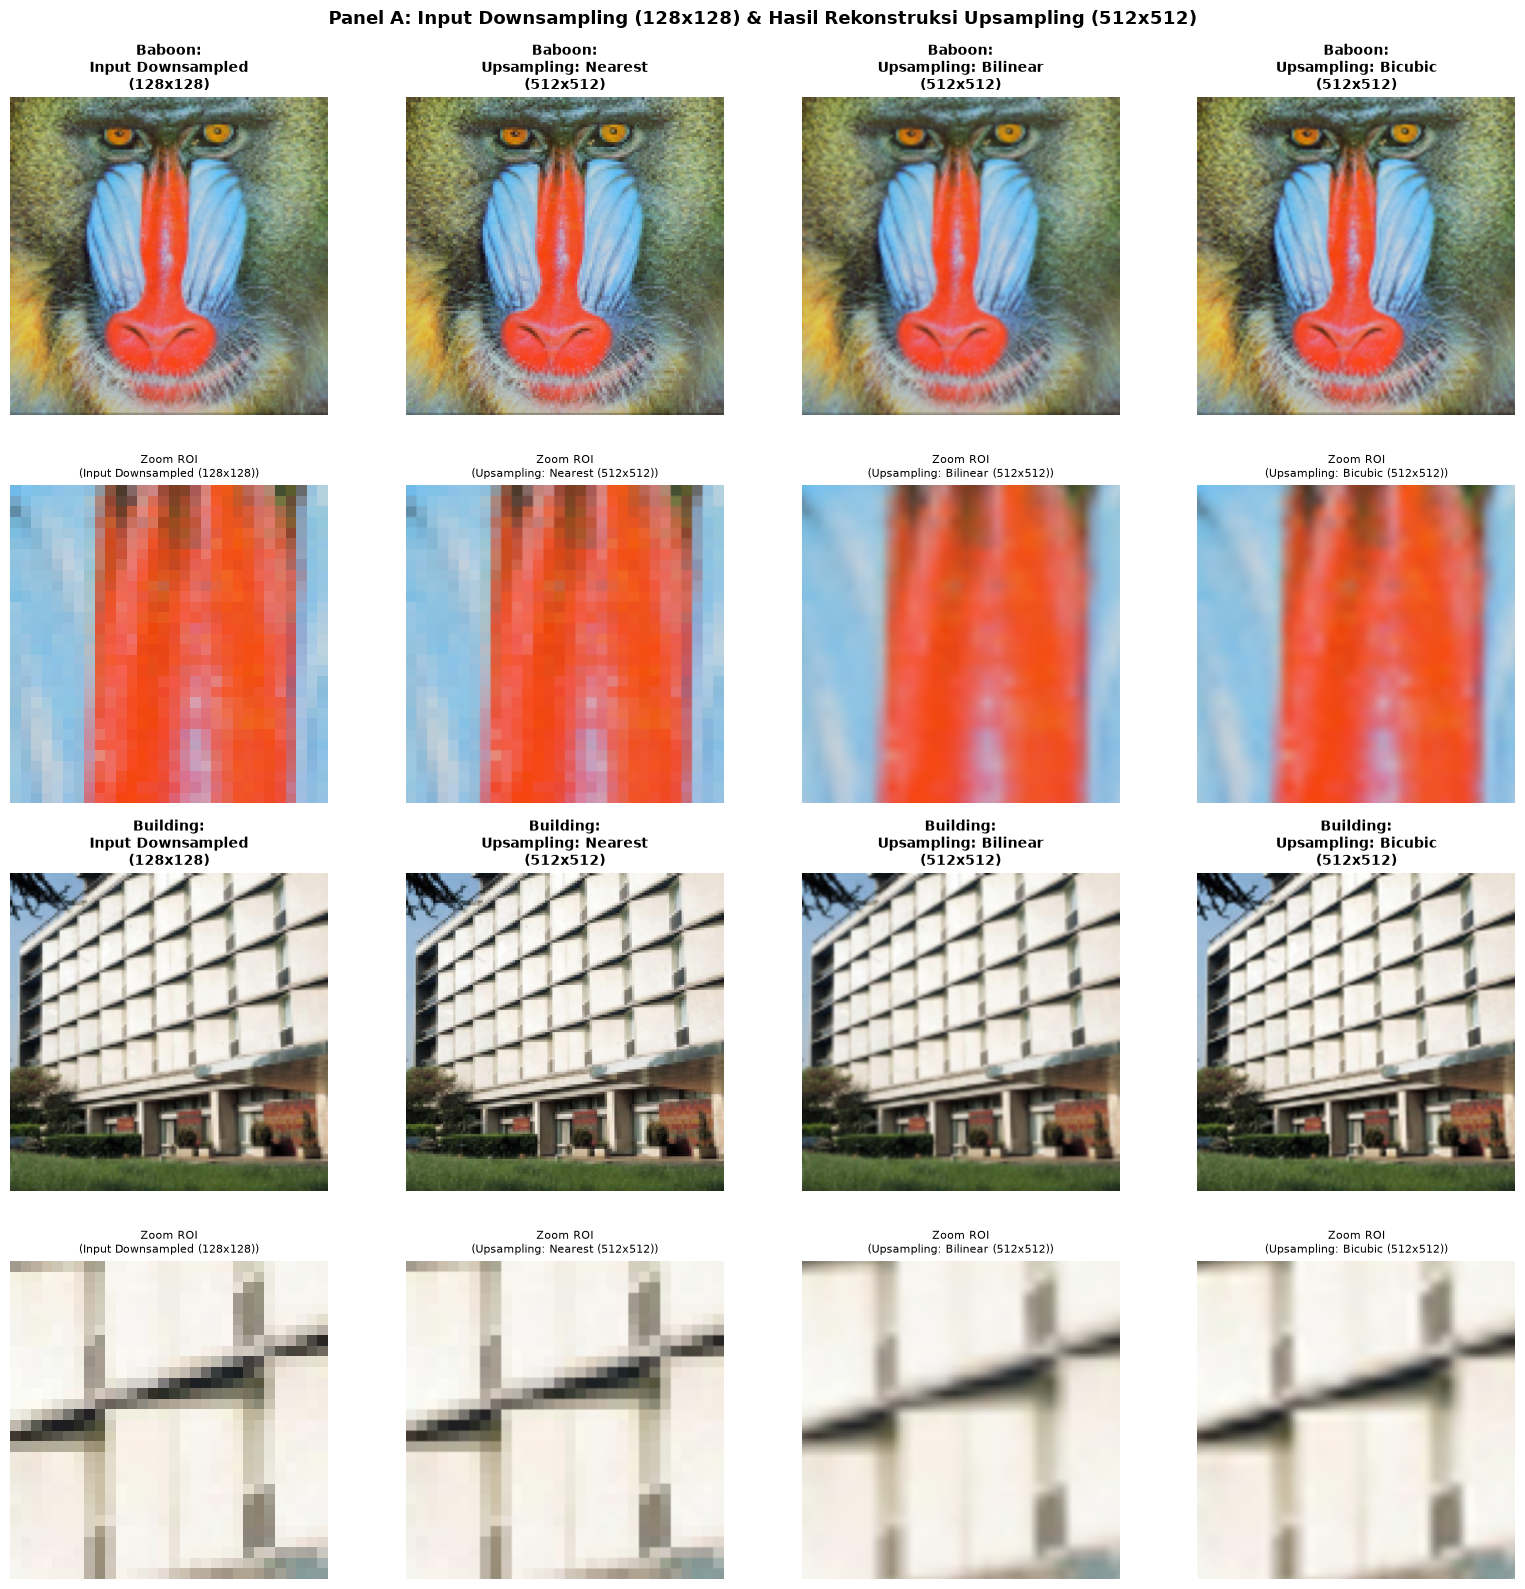

In [6]:
# Rekonstruksi Panel A: Baboon & Building
reconstructions = {}

for name in ["Baboon", "Building", "Astronaut", "Gravel"]:
    down = downsampled_results[name]["average"]
    reconstructions[name] = {
        "Nearest": upsample(down, scale_or_shape=4, method='nearest'),
        "Bilinear": upsample(down, scale_or_shape=4, method='bilinear'),
        "Bicubic": upsample(down, scale_or_shape=4, method='bicubic')
    }

print("=== Verifikasi Dimensi Citra (Input Downsampled vs Output Upsampled) ===")
for name in ["Baboon", "Building"]:
    d_shape = downsampled_results[name]["average"].shape
    u_shape = reconstructions[name]["Bicubic"].shape
    print(f"• {name:10s} : Input Downsampled {d_shape[:2]}  --->  Hasil Upsampling (4x) {u_shape[:2]}")

# Definisi ROI: [ymin, ymax, xmin, xmax]
roi_configs = {
    "Baboon": (120, 240, 180, 300),    # Mata & Kumis Halus
    "Building": (200, 320, 200, 320),  # Kisi-kisi Jendela & Kolom
    "Astronaut": (140, 260, 180, 300), # Kontur Wajah & Visor
    "Gravel": (150, 270, 150, 270)     # Agregat Kerikil
}

# Visualisasi Panel A: Baboon & Building (4 Kolom dengan Dimensi Eksplisit)
fig, axes = plt.subplots(4, 4, figsize=(16, 16))

for row_base, name in enumerate(["Baboon", "Building"]):
    down = downsampled_results[name]["average"]
    y1, y2, x1, x2 = roi_configs[name]
    
    # Koordinat ROI pada citra downsample (faktor 4x)
    dy1, dy2, dx1, dx2 = y1 // 4, y2 // 4, x1 // 4, x2 // 4
    
    methods = [
        ("Input Downsampled\n(128x128)", down, down[dy1:dy2, dx1:dx2], 'nearest'),
        ("Upsampling: Nearest\n(512x512)", reconstructions[name]["Nearest"], reconstructions[name]["Nearest"][y1:y2, x1:x2], None),
        ("Upsampling: Bilinear\n(512x512)", reconstructions[name]["Bilinear"], reconstructions[name]["Bilinear"][y1:y2, x1:x2], None),
        ("Upsampling: Bicubic\n(512x512)", reconstructions[name]["Bicubic"], reconstructions[name]["Bicubic"][y1:y2, x1:x2], None)
    ]
    
    # Baris 1: Tampilan Penuh
    for col_idx, (m_title, img_res, _, _) in enumerate(methods):
        axes[row_base * 2, col_idx].imshow(img_res)
        axes[row_base * 2, col_idx].set_title(f"{name}:\n{m_title}", fontsize=10, fontweight='bold')
        axes[row_base * 2, col_idx].axis('off')
        
        # Baris 2: Detail Zoom ROI
        roi_patch = methods[col_idx][2]
        interp = methods[col_idx][3]
        axes[row_base * 2 + 1, col_idx].imshow(roi_patch, interpolation=interp)
        clean_title = m_title.replace('\n', ' ')
        axes[row_base * 2 + 1, col_idx].set_title(f"Zoom ROI\n({clean_title})", fontsize=8)
        axes[row_base * 2 + 1, col_idx].axis('off')

plt.suptitle("Panel A: Input Downsampling (128x128) & Hasil Rekonstruksi Upsampling (512x512)", fontsize=13, fontweight='bold', y=0.99)
plt.tight_layout()
plt.savefig('data/output/panel_a_upsampling_roi.png', dpi=200, bbox_inches='tight')
plt.show()

=== Verifikasi Dimensi Citra (Input Downsampled vs Output Upsampled) ===
• Astronaut  : Input Downsampled (128, 128)  --->  Hasil Upsampling (4x) (512, 512)
• Gravel     : Input Downsampled (128, 128)  --->  Hasil Upsampling (4x) (512, 512)


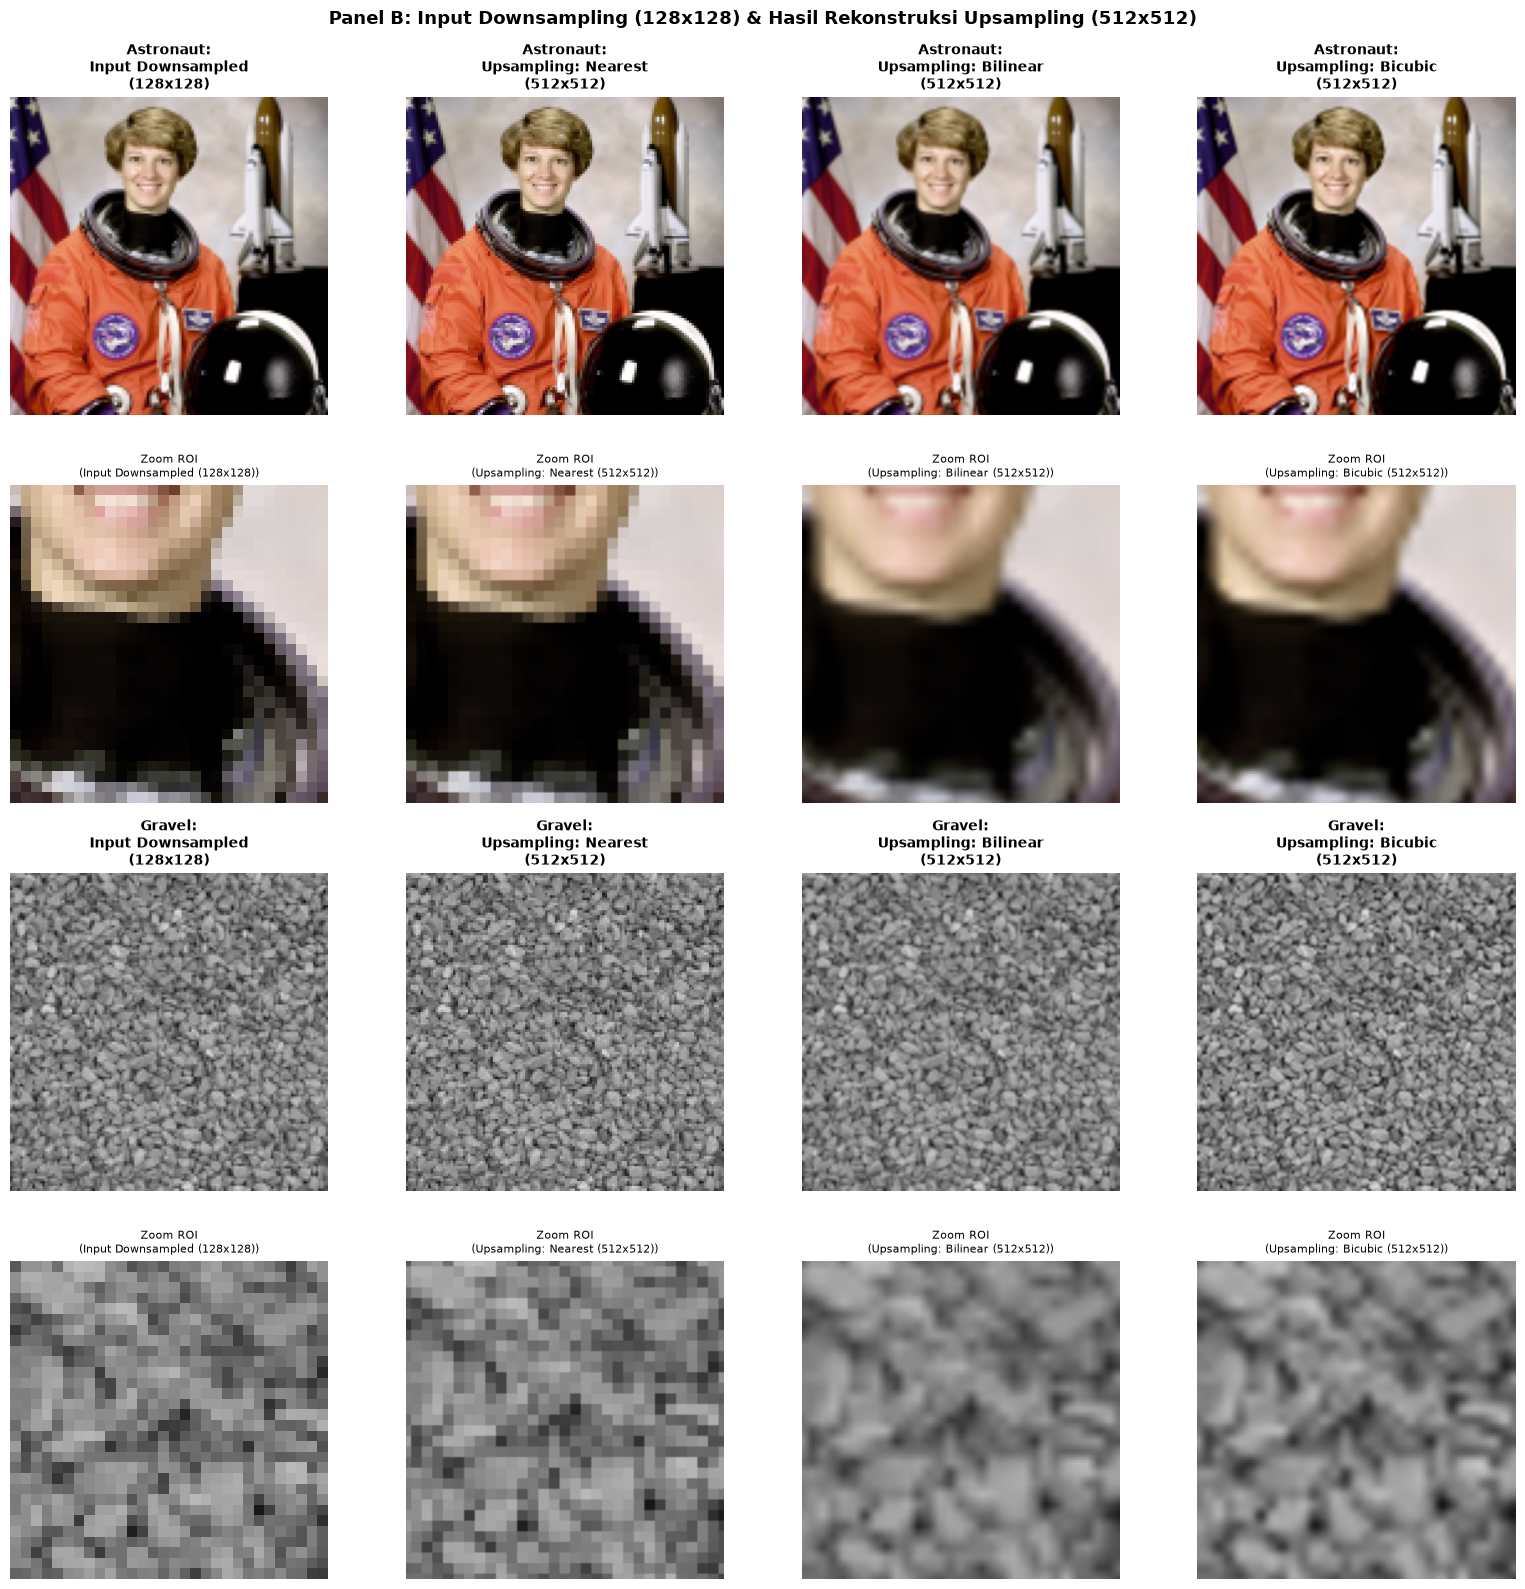

In [7]:
# Visualisasi Panel B: Astronaut & Gravel (4 Kolom dengan Dimensi Eksplisit)
print("=== Verifikasi Dimensi Citra (Input Downsampled vs Output Upsampled) ===")
for name in ["Astronaut", "Gravel"]:
    d_shape = downsampled_results[name]["average"].shape
    u_shape = reconstructions[name]["Bicubic"].shape
    print(f"• {name:10s} : Input Downsampled {d_shape[:2]}  --->  Hasil Upsampling (4x) {u_shape[:2]}")

fig, axes = plt.subplots(4, 4, figsize=(16, 16))

for row_base, name in enumerate(["Astronaut", "Gravel"]):
    down = downsampled_results[name]["average"]
    y1, y2, x1, x2 = roi_configs[name]
    
    # Koordinat ROI pada citra downsample (faktor 4x)
    dy1, dy2, dx1, dx2 = y1 // 4, y2 // 4, x1 // 4, x2 // 4
    
    methods = [
        ("Input Downsampled\n(128x128)", down, down[dy1:dy2, dx1:dx2], 'nearest'),
        ("Upsampling: Nearest\n(512x512)", reconstructions[name]["Nearest"], reconstructions[name]["Nearest"][y1:y2, x1:x2], None),
        ("Upsampling: Bilinear\n(512x512)", reconstructions[name]["Bilinear"], reconstructions[name]["Bilinear"][y1:y2, x1:x2], None),
        ("Upsampling: Bicubic\n(512x512)", reconstructions[name]["Bicubic"], reconstructions[name]["Bicubic"][y1:y2, x1:x2], None)
    ]
    
    # Baris 1: Tampilan Penuh
    for col_idx, (m_title, img_res, _, _) in enumerate(methods):
        axes[row_base * 2, col_idx].imshow(img_res)
        axes[row_base * 2, col_idx].set_title(f"{name}:\n{m_title}", fontsize=10, fontweight='bold')
        axes[row_base * 2, col_idx].axis('off')
        
        # Baris 2: Detail Zoom ROI
        roi_patch = methods[col_idx][2]
        interp = methods[col_idx][3]
        axes[row_base * 2 + 1, col_idx].imshow(roi_patch, interpolation=interp)
        clean_title = m_title.replace('\n', ' ')
        axes[row_base * 2 + 1, col_idx].set_title(f"Zoom ROI\n({clean_title})", fontsize=8)
        axes[row_base * 2 + 1, col_idx].axis('off')

plt.suptitle("Panel B: Input Downsampling (128x128) & Hasil Rekonstruksi Upsampling (512x512)", fontsize=13, fontweight='bold', y=0.99)
plt.tight_layout()
plt.savefig('data/output/panel_b_upsampling_roi.png', dpi=200, bbox_inches='tight')
plt.show()

---
## 6. Evaluasi Kuantitatif (MSE, PSNR, dan SSIM)

Evaluasi kuantitatif dilakukan untuk mengukur fidelitas rekonstruksi terhadap citra referensi asli:
- **Mean Squared Error (MSE)**: Rata-rata kuadrat error piksel (semakin rendah semakin baik).
- **Peak Signal-to-Noise Ratio (PSNR)**: Rasio sinyal terhadap noise dalam desibel (dB) (semakin tinggi semakin baik).
- **Structural Similarity Index (SSIM)**: Kesamaan perseptual struktur citra berkisar 0 hingga 1 (semakin mendekati 1 semakin sempurna).


    Citra Karakteristik Metode Interpolasi    MSE  PSNR (dB)   SSIM
   Baboon       Tekstur            Nearest 580.01      20.50 0.4677
   Baboon       Tekstur           Bilinear 568.28      20.59 0.4370
   Baboon       Tekstur            Bicubic 542.69      20.79 0.4715
 Building          Tepi            Nearest 337.35      22.85 0.7700
 Building          Tepi           Bilinear 232.24      24.47 0.7986
 Building          Tepi            Bicubic 174.42      25.71 0.8265
Astronaut       Gradien            Nearest 297.48      23.40 0.7834
Astronaut       Gradien           Bilinear 226.66      24.58 0.8083
Astronaut       Gradien            Bicubic 188.13      25.39 0.8361
   Gravel          Pola            Nearest 510.30      21.05 0.6024
   Gravel          Pola           Bilinear 455.64      21.54 0.5980
   Gravel          Pola            Bicubic 385.08      22.28 0.6586


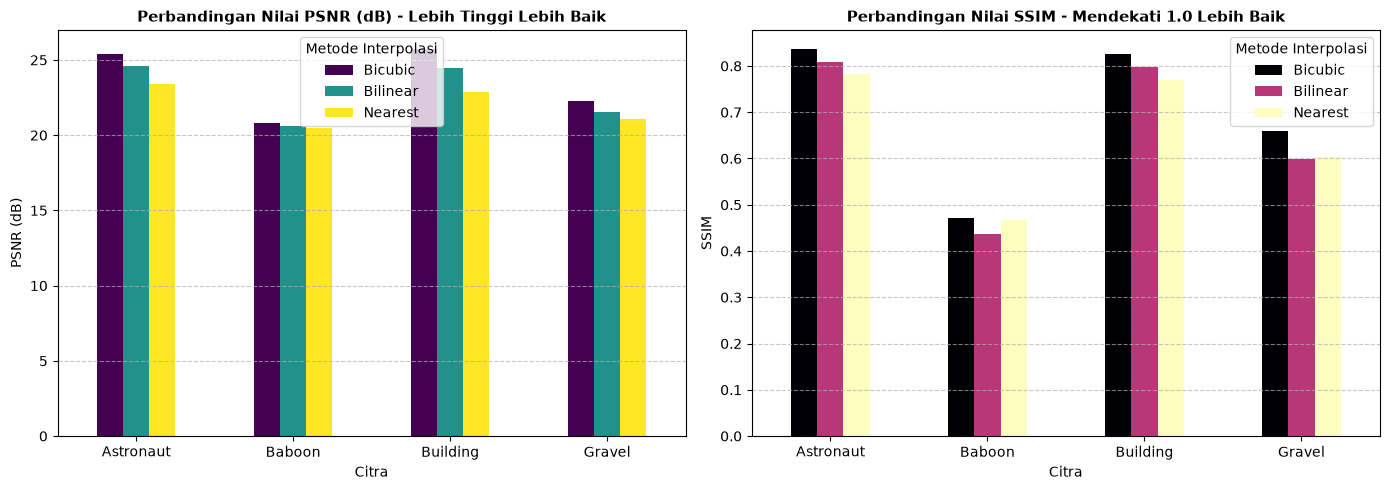

In [8]:
def evaluate_metrics(img_ref: np.ndarray, img_test: np.ndarray) -> dict:
    """Menghitung metrik kuantitatif fidelitas rekonstruksi: MSE, PSNR (dB), dan SSIM."""
    diff = img_ref.astype(np.float64) - img_test.astype(np.float64)
    mse = float(np.mean(diff ** 2))
    psnr = float('inf') if mse <= 1e-10 else float(20.0 * np.log10(255.0 / np.sqrt(mse)))
    channel_axis = 2 if img_ref.ndim == 3 else None
    ssim = float(ssim_fn(img_ref, img_test, channel_axis=channel_axis, data_range=255.0))
    return {"MSE": round(mse, 2), "PSNR (dB)": round(psnr, 2), "SSIM": round(ssim, 4)}

# Eksekusi Evaluasi Kuantitatif Rekonstruksi 4x
records = []

for name, item in benchmark_dataset.items():
    orig = item["img"]
    for m_name in ["Nearest", "Bilinear", "Bicubic"]:
        recon = reconstructions[name][m_name]
        m = evaluate_metrics(orig, recon)
        m["Citra"] = name
        m["Karakteristik"] = item["desc"].split()[0]
        m["Metode Interpolasi"] = m_name
        records.append(m)

df_results = pd.DataFrame(records)[["Citra", "Karakteristik", "Metode Interpolasi", "MSE", "PSNR (dB)", "SSIM"]]
print(df_results.to_string(index=False))

# Visualisasi Grafik Batang Metrik untuk Keempat Citra
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df_pivot_psnr = df_results.pivot(index='Citra', columns='Metode Interpolasi', values='PSNR (dB)')
df_pivot_ssim = df_results.pivot(index='Citra', columns='Metode Interpolasi', values='SSIM')

df_pivot_psnr.plot(kind='bar', ax=axes[0], colormap='viridis', rot=0)
axes[0].set_title("Perbandingan Nilai PSNR (dB) - Lebih Tinggi Lebih Baik", fontsize=11, fontweight='bold')
axes[0].set_ylabel("PSNR (dB)")
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

df_pivot_ssim.plot(kind='bar', ax=axes[1], colormap='magma', rot=0)
axes[1].set_title("Perbandingan Nilai SSIM - Mendekati 1.0 Lebih Baik", fontsize=11, fontweight='bold')
axes[1].set_ylabel("SSIM")
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


---
## 7. Kesimpulan dan Analisis Komparatif

Berdasarkan hasil pengujian terhadap 4 citra dengan karakteristik frekuensi dan spasial yang berbeda:

### 1. Karakteristik Downsampling
* **Max Downsampling** memicu kenaikan kecerahan (*brightening bias*) di seluruh citra. Pada *Baboon* dan *Gravel*, piksel terang melebar dan menutupi tekstur gelap di sekitarnya. Metode ini cocok untuk ekstraksi fitur invarian pada arsitektur CNN, namun tidak disarankan untuk kompresi citra fotografi biasa.
* **Average Downsampling** paling unggul dalam menjaga rata-rata intensitas citra melalui karakteristik filter perata (*low-pass filter*), menjadikannya basis reduksi resolusi yang paling seimbang sebelum rekonstruksi upsampling.
* **Median Downsampling** mempertahankan ketajaman garis tepi (*edge boundaries*) lebih baik daripada average downsampling dan tidak menimbulkan pergeseran kecerahan global. Metode ini sangat cocok untuk citra bertekstur teratur atau yang memiliki gangguan *salt-and-pepper noise*.

### 2. Karakteristik Rekonstruksi Upsampling
* **Nearest Neighbor (NN)** (tanpa perhitungan tetangga) mempertahankan kontras lokal, namun menghasilkan efek kotak-kotak (*blocky pixelation / jaggies*) yang kasar pada garis jendela gedung, mata baboon, maupun kerikil. Metode ini menghasilkan skor PSNR dan SSIM terendah di seluruh citra uji.
* **Bilinear Interpolation** (memperhitungkan 4 piksel tetangga) menghilangkan efek kotak-kotak melalui interpolasi linier dua arah, namun menimbulkan sedikit keburaman (*smoothing blur*) pada area tepi yang tajam.
* **Bicubic Interpolation** (memperhitungkan 16 piksel tetangga) secara konsisten menghasilkan skor **PSNR dan SSIM tertinggi** di keempat citra. Konvolusi kubik Keys berhasil merekonstruksi kelengkungan kontur alami wajah baboon/astronot dan garis lurus jendela bangunan dengan hasil yang lebih tajam dan alami.

### 3. Pengaruh Karakteristik Citra Terhadap Resampling
* **Citra Tekstur Tinggi (*Baboon*)**: Mengalami degradasi informasi paling besar akibat hilangnya detail frekuensi spasial tinggi di atas batas Nyquist, menghasilkan PSNR terendah (~20.5 dB).
* **Citra Tepi Geometris (*Building*) & Gradasi Halus (*Astronaut*)**: Memperoleh pemulihan kualitas terbaik pada interpolasi Bicubic (PSNR mencapai 25.4 - 25.7 dB dan SSIM di atas 0.82), menunjukkan bahwa keteraturan geometris dan kontinuitas gradasi warna sangat cocok direkonstruksi dengan aproksimasi spline orde tinggi.